In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from node2vec import Node2Vec

MERCHANT_FILE = "merchant_synthetic_100k.csv"
EDGE_FILE = "merchant_edges.csv"
OUTPUT_FILE = "merchant_synthetic_100k_embeddings.csv"

EMBED_DIM = 16
RANDOM_SEED = 42

print("Loading merchant + edge data...")


df = pd.read_csv(MERCHANT_FILE, dtype={"merchant_id": str})
edges = pd.read_csv(
    EDGE_FILE,
    dtype={"merchant_A": str, "merchant_B": str}
)


df["merchant_id"] = df["merchant_id"].str.strip()
edges["merchant_A"] = edges["merchant_A"].str.strip()
edges["merchant_B"] = edges["merchant_B"].str.strip()

required_merchant = {"merchant_id"}
required_edges = {"merchant_A", "merchant_B", "weight"}

if not required_merchant.issubset(df.columns):
    raise ValueError("merchant_id column is missing.")

if not required_edges.issubset(edges.columns):
    raise ValueError("Required edge columns are missing.")

if df["merchant_id"].isna().any():
    raise ValueError("Merchant IDs contain missing values.")

if df["merchant_id"].duplicated().any():
    raise ValueError("Duplicate merchant IDs found.")

print("Merchants:", df.shape)
print("Edges:", edges.shape)

print("\nBuilding merchant graph...")

G = nx.Graph()

merchant_ids = df["merchant_id"].tolist()
G.add_nodes_from(merchant_ids)


edges["weight"] = pd.to_numeric(edges["weight"], errors="coerce")
edges = edges.dropna(subset=["merchant_A", "merchant_B", "weight"])


merchant_set = set(merchant_ids)

edges = edges[
    edges["merchant_A"].isin(merchant_set)
    & edges["merchant_B"].isin(merchant_set)
]


edges = edges[edges["merchant_A"] != edges["merchant_B"]]


edge_tuples = edges[
    ["merchant_A", "merchant_B", "weight"]
].itertuples(index=False, name=None)

G.add_weighted_edges_from(edge_tuples)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges before noise:", G.number_of_edges())


print("\nAdding noise edges...")

rng = np.random.default_rng(RANDOM_SEED)

N = len(merchant_ids)
noise_count = N // 50


noise_a = rng.choice(merchant_ids, size=noise_count)
noise_b = rng.choice(merchant_ids, size=noise_count)

noise_weights = rng.choice(
    [1, 2, 3],
    size=noise_count,
    p=[0.6, 0.3, 0.1]
)


valid_mask = noise_a != noise_b

noise_edges = [
    (a, b, int(w))
    for a, b, w in zip(
        noise_a[valid_mask],
        noise_b[valid_mask],
        noise_weights[valid_mask]
    )
]

G.add_weighted_edges_from(noise_edges)

print("Graph edges after noise:", G.number_of_edges())

print("\nRunning Node2Vec...")

node2vec = Node2Vec(
    G,
    dimensions=EMBED_DIM,
    walk_length=10,
    num_walks=5,
    p=1.0,
    q=1.0,
    workers=1,
    seed=RANDOM_SEED,
    quiet=True
)

print("Training Node2Vec model...")

model = node2vec.fit(
    window=5,
    min_count=1,
    batch_words=4,
    epochs=1,
    seed=RANDOM_SEED
)

print("Node2Vec training completed.")


print("\nExtracting embeddings...")


embeddings = np.array(
    [model.wv[node] for node in merchant_ids],
    dtype=np.float32
)

embed_columns = [
    f"emb_{i}" for i in range(EMBED_DIM)
]

embed_df = pd.DataFrame(
    embeddings,
    columns=embed_columns
)

embed_df.insert(0, "merchant_id", merchant_ids)

print("Embeddings shape:", embed_df.shape)

print("\nMerging embeddings...")

df_final = df.merge(
    embed_df,
    on="merchant_id",
    how="left",
    validate="one_to_one"
)


if df_final[embed_columns].isna().any().any():
    raise ValueError("Some merchant embeddings are missing.")

print("Final dataframe shape:", df_final.shape)

df_final.to_csv(OUTPUT_FILE, index=False)

print("\nPHASE 6 DONE")
print("Saved:", OUTPUT_FILE)
print("Total merchants:", len(df_final))
print("Embedding dimensions:", EMBED_DIM)
print("Total features:", df_final.shape[1])


Loading merchant + edge data...
Merchants: (100000, 34)
Edges: (11015, 4)

Building merchant graph...
Graph nodes: 100000
Graph edges before noise: 11015

Adding noise edges...
Graph edges after noise: 13015

Running Node2Vec...
Training Node2Vec model...
Node2Vec training completed.

Extracting embeddings...
Embeddings shape: (100000, 17)

Merging embeddings...
Final dataframe shape: (100000, 50)

PHASE 6 DONE
Saved: merchant_synthetic_100k_embeddings.csv
Total merchants: 100000
Embedding dimensions: 16
Total features: 50


In [2]:
import pandas as pd

df = pd.read_csv("merchant_synthetic_100k.csv")

print("Total columns:", len(df.columns))
print("\nFeature List:")
for col in df.columns:
    print(col)


Total columns: 34

Feature List:
merchant_id
is_fraud
merchant_registration_date
merchant_category
business_city
merchant_tier
is_kyc_verified
pan_hash
device_id_hash
ip_hash
total_txns_90d
avg_txn_value
chargeback_rate
refund_ratio
merchant_age_days
total_txns_30d
total_txns_7d
avg_txn_value_30d
median_txn_value_90d
std_txn_value_90d
min_txn_value_30d
max_txn_value_30d
pct_high_value_txns
high_value_txns_90d
high_value_txns_30d
shared_pan_count
shared_device_count
shared_ip_count
phone_hash
email_hash
pos_terminal_id_hash
shared_phone_count
shared_email_count
shared_pos_terminal_count


Non-embedding features: 34
['merchant_id', 'is_fraud', 'merchant_registration_date', 'merchant_category', 'business_city', 'merchant_tier', 'is_kyc_verified', 'pan_hash', 'device_id_hash', 'ip_hash', 'total_txns_90d', 'avg_txn_value', 'chargeback_rate', 'refund_ratio', 'merchant_age_days', 'total_txns_30d', 'total_txns_7d', 'avg_txn_value_30d', 'median_txn_value_90d', 'std_txn_value_90d', 'min_txn_value_30d', 'max_txn_value_30d', 'pct_high_value_txns', 'high_value_txns_90d', 'high_value_txns_30d', 'shared_pan_count', 'shared_device_count', 'shared_ip_count', 'phone_hash', 'email_hash', 'pos_terminal_id_hash', 'shared_phone_count', 'shared_email_count', 'shared_pos_terminal_count']


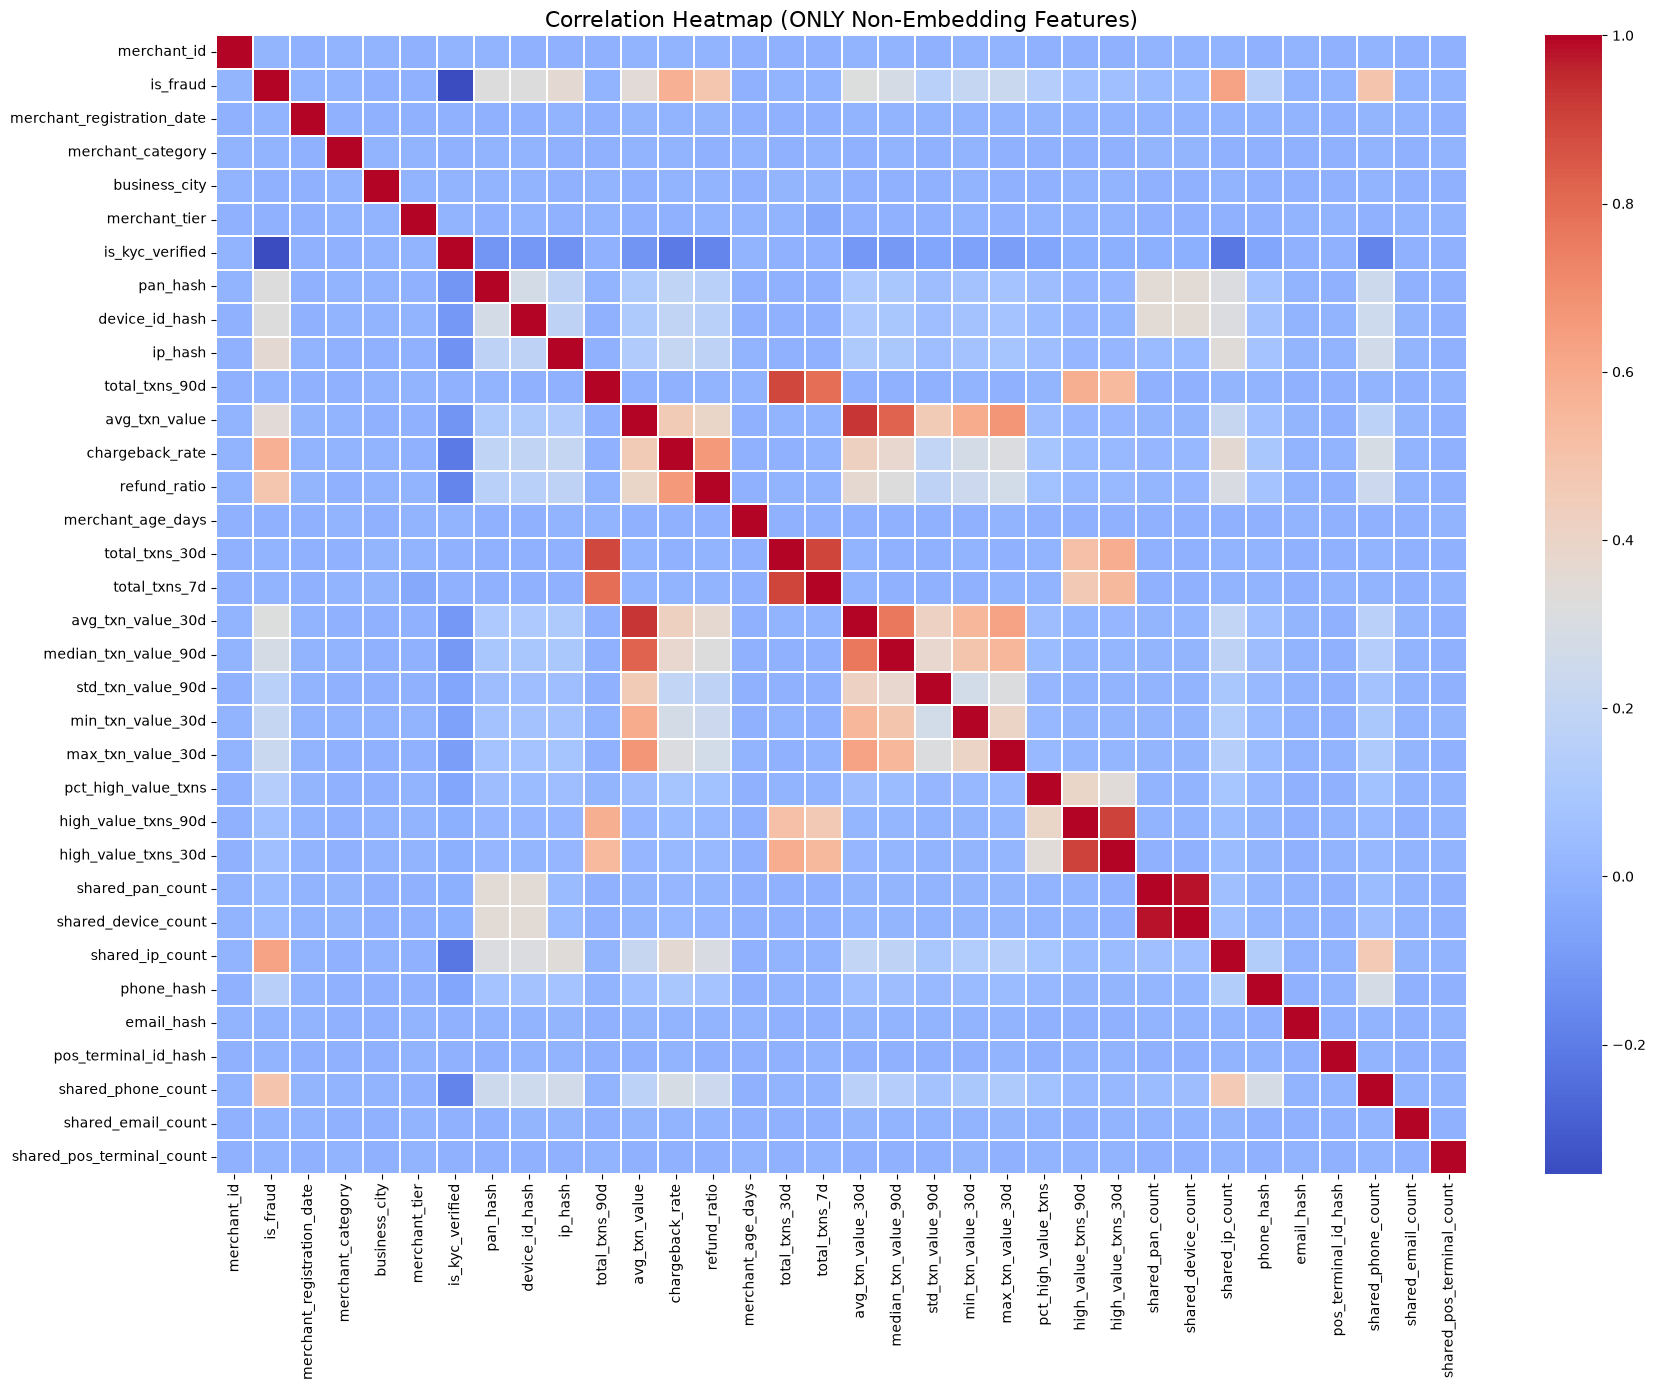

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("merchant_synthetic_100k.csv")


non_embed_df = df[[c for c in df.columns if not c.startswith("emb_")]].copy()

print("Non-embedding features:", len(non_embed_df.columns))
print(non_embed_df.columns.tolist())


label_cols = non_embed_df.select_dtypes(include=["object", "str"]).columns


le = LabelEncoder()

for col in label_cols:
    non_embed_df[col] = le.fit_transform(non_embed_df[col].astype(str))

corr = non_embed_df.corr(numeric_only=True)


plt.figure(figsize=(18, 14))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.3
)

plt.title("Correlation Heatmap (ONLY Non-Embedding Features)", fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("merchant_synthetic_100k.csv")

print("Original shape:", df.shape)


cols_to_remove = [
    "merchant_registration_date",
    "merchant_age_days",
    "pan_hash",
    "device_id_hash",
    "ip_hash",
    "phone_hash",
    "pos_terminal_id_hash",
    "email_hash",
    "business_city" 
]

df = df.drop(columns=cols_to_remove)
print("After removing columns:", df.shape)

y = df["is_fraud"]
X = df.drop(columns=["is_fraud", "merchant_id"])  

categorical_cols = ["merchant_tier", "merchant_category"]

print("Encoding categorical columns:", categorical_cols)

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Final X matrix shape:", X.shape)
print("Final feature list:")
print(list(X.columns))


Original shape: (100000, 34)
After removing columns: (100000, 25)
Encoding categorical columns: ['merchant_tier', 'merchant_category']
Final X matrix shape: (100000, 23)
Final feature list:
['merchant_category', 'merchant_tier', 'is_kyc_verified', 'total_txns_90d', 'avg_txn_value', 'chargeback_rate', 'refund_ratio', 'total_txns_30d', 'total_txns_7d', 'avg_txn_value_30d', 'median_txn_value_90d', 'std_txn_value_90d', 'min_txn_value_30d', 'max_txn_value_30d', 'pct_high_value_txns', 'high_value_txns_90d', 'high_value_txns_30d', 'shared_pan_count', 'shared_device_count', 'shared_ip_count', 'shared_phone_count', 'shared_email_count', 'shared_pos_terminal_count']


Train shape: (75000, 23)
Test shape: (25000, 23)
Scale_pos_weight: 8.090909090909092

Training XGBoost...

ACCURACY: 0.96472

CONFUSION MATRIX:
[[21655   595]
 [  287  2463]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     22250
           1       0.81      0.90      0.85      2750

    accuracy                           0.96     25000
   macro avg       0.90      0.93      0.91     25000
weighted avg       0.97      0.96      0.97     25000



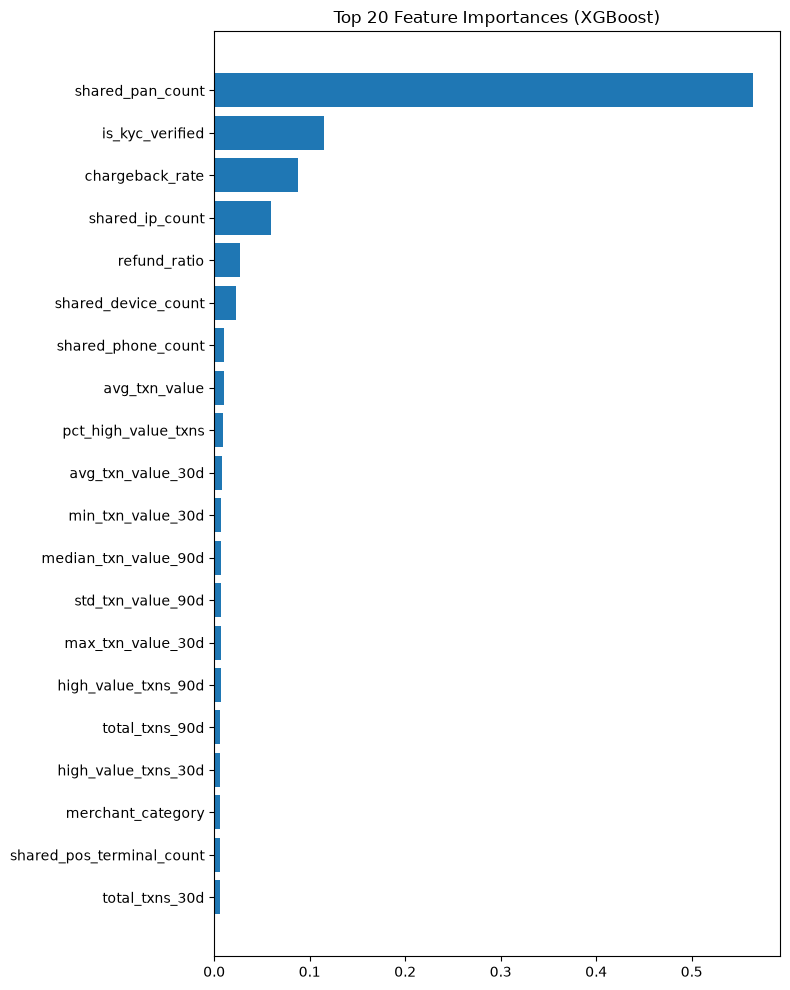

In [5]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


fraud_ratio = y.mean()
scale_pos_weight = (1 - fraud_ratio) / fraud_ratio
print("Scale_pos_weight:", scale_pos_weight)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.07,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight
)

print("\nTraining XGBoost...")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nACCURACY:", accuracy_score(y_test, y_pred))
print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

import matplotlib.pyplot as plt

importance = model.feature_importances_
feat_names = X.columns

sorted_idx = importance.argsort()[-20:]  # Top 20 features

plt.figure(figsize=(8, 10))
plt.barh(feat_names[sorted_idx], importance[sorted_idx])
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import plotly.graph_objects as go
from community import community_louvain


print("Loading merchant data and edges...")
df = pd.read_csv("merchant_synthetic_100k.csv")
edges = pd.read_csv("merchant_edges.csv")

print(f"Total merchants: {len(df)}")
print(f"Total edges: {len(edges)}")

fraud_merchants = set(df[df["is_fraud"] == 1]["merchant_id"].tolist())
print(f"Fraud merchants: {len(fraud_merchants)}")


fraud_edges = edges[
    (edges["merchant_A"].isin(fraud_merchants)) & 
    (edges["merchant_B"].isin(fraud_merchants))
].copy()

print(f"Edges between fraud merchants: {len(fraud_edges)}")

print("\nBuilding fraud network graph...")

G = nx.Graph()
G.add_nodes_from(fraud_merchants)


for _, row in fraud_edges.iterrows():
    G.add_edge(
        row["merchant_A"], 
        row["merchant_B"], 
        weight=row["weight"],
        reason=row["reason"]
    )

print(f"Graph nodes: {G.number_of_nodes()}")
print(f"Graph edges: {G.number_of_edges()}")

print("\nDetecting communities using Louvain algorithm...")

partition = community_louvain.best_partition(G, weight="weight")
nx.set_node_attributes(G, partition, "community")

print(f"Communities detected: {len(set(partition.values()))}")


from collections import Counter

comm_counts = Counter(partition.values())
largest_comm = comm_counts.most_common(1)[0][0]
comm_size = comm_counts.most_common(1)[0][1]

print(f"\nLargest community ID: {largest_comm}")
print(f"Largest community size: {comm_size} merchants")

sub_nodes = [n for n, c in partition.items() if c == largest_comm]
H = G.subgraph(sub_nodes).copy()

print(f"Subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")


print("\nCalculating node positions (spring layout)...")

pos = nx.spring_layout(H, seed=42, weight="weight", iterations=50, k=0.5)


x_nodes = [pos[n][0] for n in H.nodes()]
y_nodes = [pos[n][1] for n in H.nodes()]


edge_x, edge_y = [], []
for edge in H.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    hoverinfo="none",
    line=dict(width=0.5, color="#888888"),
    name="Edges"
)


node_trace = go.Scatter(
    x=x_nodes,
    y=y_nodes,
    mode="markers",
    hoverinfo="text",
    marker=dict(
        showscale=True,
        colorscale="Turbo",
        color=[partition[n] for n in H.nodes()],
        size=10,
        line=dict(width=1, color="white"),
        colorbar=dict(
            title=dict(text="Community ID"),
            thickness=15,
            len=0.7
        )
    ),
    text=[f"Merchant: {n}<br>Community: {partition[n]}" for n in H.nodes()],
    name="Merchants"
)


fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=dict(
            text=f"Fraud Network Visualization (Largest Community - {comm_size} merchants)",
            font=dict(size=22, color="#2c3e50"),
            x=0.5,
            xanchor="center"
        ),
        showlegend=False,
        hovermode="closest",
        margin=dict(b=20, l=5, r=5, t=80),
        plot_bgcolor="rgba(240, 240, 240, 0.9)",
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        width=1200,
        height=800
    )
)

fig.show()


print("\n" + "="*60)
print("COMMUNITY STATISTICS")
print("="*60)

all_communities = sorted(set(partition.values()))
for comm_id in all_communities[:10]:  # Top 10 communities
    comm_merchants = [n for n, c in partition.items() if c == comm_id]
    comm_edges = H.subgraph(comm_merchants).number_of_edges() if len(comm_merchants) > 1 else 0
    print(f"Community {comm_id}: {len(comm_merchants)} merchants, {comm_edges} edges")


print("\n" + "="*60)
print("Saving community analysis...")
print("="*60)


community_data = []
for merchant_id, comm_id in partition.items():
    community_data.append({
        'merchant_id': merchant_id,
        'community_id': comm_id
    })

comm_df = pd.DataFrame(community_data)
comm_df.to_csv("merchant_communities.csv", index=False)
print("✓ Saved: merchant_communities.csv")


largest_comm_df = pd.DataFrame({'merchant_id': sub_nodes})
largest_comm_df = largest_comm_df.merge(
    df[['merchant_id', 'merchant_tier', 'merchant_category', 'is_kyc_verified', 'avg_txn_value', 'chargeback_rate']],
    on='merchant_id'
)
largest_comm_df.to_csv("largest_fraud_community_merchants.csv", index=False)
print("✓ Saved: largest_fraud_community_merchants.csv")

print("\n✓ FRAUD NETWORK VISUALIZATION COMPLETE")

Loading merchant data and edges...
Total merchants: 100000
Total edges: 11015
Fraud merchants: 11000
Edges between fraud merchants: 11015

Building fraud network graph...
Graph nodes: 11000
Graph edges: 11015

Detecting communities using Louvain algorithm...
Communities detected: 1083

Largest community ID: 19
Largest community size: 43 merchants
Subgraph: 43 nodes, 58 edges

Calculating node positions (spring layout)...



COMMUNITY STATISTICS
Community 0: 13 merchants, 0 edges
Community 1: 11 merchants, 0 edges
Community 2: 13 merchants, 0 edges
Community 3: 8 merchants, 0 edges
Community 4: 5 merchants, 0 edges
Community 5: 12 merchants, 0 edges
Community 6: 11 merchants, 0 edges
Community 7: 12 merchants, 0 edges
Community 8: 11 merchants, 0 edges
Community 9: 10 merchants, 0 edges

Saving community analysis...
✓ Saved: merchant_communities.csv
✓ Saved: largest_fraud_community_merchants.csv

✓ FRAUD NETWORK VISUALIZATION COMPLETE
